# ReciPI: Auto Recipe Generation
This project uses edge computing to identify food ingredients in real-time and recommend recipes based on what you have available. Running entirely on a Raspberry Pi 3, the system uses a connected Pi Camera to capture images of ingredients, runs inference locally using a lightweight, quantized and prunned ResNet-18 model, and uses a recipe database to suggest a recipe using detected ingredient

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision.models as models
import kagglehub
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import namedtuple
from fast_pytorch_kmeans import KMeans

#Global
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Codebook = namedtuple('Codebook', ['centroids', 'labels'])

In [2]:
#HyperParameters
batch_size = 32
learning_rate = 1e-4
num_epochs = 15
patience = 3

### Dataset Initialization & Loaders

In [3]:
# Download Dataset
path = kagglehub.dataset_download("evan15h/cooking-ingredients-dataset")
train_dir = os.path.join(path, "cooking-ingredients-dataset", "train")
val_dir = os.path.join(path, "cooking-ingredients-dataset", "val")

# Extract Classes
tmp_dataset = datasets.ImageFolder(root=train_dir)
ingredients = tmp_dataset.classes
CLASS_NUMBER = len(ingredients)

# Create & Save JSON Mappings
id2label = {str(i): name for i, name in enumerate(ingredients)}
label2id = {name: str(i) for i, name in enumerate(ingredients)}
os.makedirs("../JSON", exist_ok=True)
with open("../JSON/id2label_produce.json", "w") as f: json.dump(id2label, f, indent=2)
with open("../JSON/label2id_produce.json", "w") as f: json.dump(label2id, f, indent=2)

# Transforms & Normalization
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
with open("../JSON/norm_stats_produce_newdata.json", "w") as f: json.dump({"mean": mean, "std": std}, f, indent=2)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.25, hue=0.04),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.5))], p=0.5),
    transforms.RandomApply([transforms.RandomPerspective(distortion_scale=0.25, p=1.0)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# Loaders
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_dir, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Dataset Loaded -> Classes: {CLASS_NUMBER} | Train Imgs: {len(train_dataset)} | Val Imgs: {len(val_dataset)}")

Dataset Loaded -> Classes: 31 | Train Imgs: 3873 | Val Imgs: 964


### Functions

In [4]:
def get_base_model():
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, CLASS_NUMBER)
    return model.to(DEVICE)

def unpack_4bit_model(model_path):
    model = get_base_model()
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint.get('metadata', checkpoint), strict=False)
    
    codebooks, modules_dict = {}, dict(model.named_modules())
    for name, data in checkpoint.items():
        if name == 'metadata' or not isinstance(data, dict): continue
        p = data['packed_indices']
        num_elements = torch.Size(data['shape']).numel()
        labels = torch.stack([(p >> 4) & 0x0F, p & 0x0F], dim=1).view(-1)[:num_elements]
        
        centroids = data['centroids']
        w = centroids[labels.long()].view(data['shape'])
        z_idx = data.get('zero_idx', torch.abs(centroids).argmin().item())
        w[labels.view_as(w) == z_idx] = 0.0
        
        modules_dict[name].weight.data = w.to(DEVICE)
        
        class CodebookPlaceholder:
            def __init__(self, l, c, z): self.labels, self.centroids, self.zero_idx = l, c, z
        codebooks[name] = CodebookPlaceholder(labels.to(DEVICE), centroids.to(DEVICE), z_idx)
    return model.eval(), codebooks

def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            correct += (model(images).argmax(1) == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

# --- PLOTTING LOGIC ---
def plot_training_progress(history):
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history['epoch'], history['loss'], label='Loss', color='crimson', linewidth=2)
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Training Loss', color='crimson', fontweight='bold')
    
    ax2 = ax1.twinx()
    ax2.plot(history['epoch'], history['acc'], label='Accuracy', color='royalblue', linewidth=2)
    ax2.set_ylabel('Accuracy (%)', color='royalblue', fontweight='bold')
    ax1.set_title('Training Loss & Accuracy', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    ax3.plot(history['epoch'], history['sparsity'], label='Actual Sparsity', color='forestgreen', marker='o', linewidth=2)
    ax3.axhline(y=0.6, color='gray', linestyle='--', label='Target Max (60%)')
    ax3.set_xlabel('Epochs', fontweight='bold')
    ax3.set_ylabel('Fraction of Zeros', fontweight='bold')
    ax3.set_title('Pruning Schedule', fontsize=14)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_weight_distributions(layer_name='layer1.0.conv1'):
    orig_model = get_base_model()
    orig_model.load_state_dict(torch.load("resnet18_pruned.pth", weights_only=True))
    orig_weights = dict(orig_model.named_modules())[layer_name].weight.data.cpu().numpy().flatten()
    
    quant_checkpoint = torch.load("resnet18_4bit_packed.pth", weights_only=False)
    data = quant_checkpoint[layer_name]
    p = data['packed_indices']
    labels = torch.stack([(p >> 4) & 0x0F, p & 0x0F], dim=1).view(-1)[:torch.Size(data['shape']).numel()]
    quant_weights = data['centroids'][labels.long()].cpu().numpy().flatten()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    ax1.hist(orig_weights, bins=150, color='royalblue', alpha=0.8, edgecolor='black', linewidth=0.2)
    ax1.set_title(f'Before: {layer_name} (FP32 Pruned)', fontsize=14)
    ax1.set_xlabel('Weight Value')
    ax1.set_ylabel('Frequency')
    ax1.text(0.95, 0.95, f"Unique Weights: {len(np.unique(orig_weights)):,}", transform=ax1.transAxes, ha='right', va='top', bbox=dict(facecolor='white', alpha=0.8))
    
    ax2.hist(quant_weights, bins=150, color='crimson', alpha=0.8, edgecolor='black', linewidth=0.2)
    ax2.set_title(f'After: {layer_name} (4-Bit Centroids)', fontsize=14)
    ax2.set_xlabel('Weight Value')
    ax2.text(0.95, 0.95, f"Unique Clusters: {len(np.unique(quant_weights))}", transform=ax2.transAxes, ha='right', va='top', bbox=dict(facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()

def plot_final_benchmarks(acc_orig, size_orig, acc_quant, size_quant):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    labels = ['Baseline\n(32-bit FP)', 'Compressed\n(4-bit Packed)']
    
    bars1 = ax1.bar(labels, [acc_orig, acc_quant], color=['royalblue', 'forestgreen'], edgecolor='black', width=0.5)
    ax1.set_ylabel('Validation Accuracy (%)', fontweight='bold')
    ax1.set_title('Accuracy Preservation', fontsize=14)
    ax1.set_ylim(0, 100)
    for bar in bars1: ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height():.2f}%", ha='center', fontweight='bold')

    bars2 = ax2.bar(labels, [size_orig, size_quant], color=['slategray', 'crimson'], edgecolor='black', width=0.5)
    ax2.set_ylabel('File Size (MB)', fontweight='bold')
    ax2.set_title('Disk Space Reduction', fontsize=14)
    ax2.set_ylim(0, max(size_orig, size_quant) * 1.2)
    for bar in bars2: ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{bar.get_height():.2f} MB", ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

### Phase 1: Training & Pruning

=== PHASE 1: PRUNING ===


/home/arberube/ODDL/labEnv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/arberube/ODDL/labEnv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/arberube/ODDL/labEnv/lib/python3.13/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1 | Loss: 0.8850 | Acc: 81.13% | Sparsity: 0.0000


/home/arberube/ODDL/labEnv/lib/python3.13/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2 | Loss: 0.1787 | Acc: 96.49% | Sparsity: 0.0000


...

Epoch 13 | Loss: 0.0367 | Acc: 99.56% | Sparsity: 0.3439
 -> Pruning to Target Sparsity: 0.50


/home/arberube/ODDL/labEnv/lib/python3.13/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 14 | Loss: 0.0501 | Acc: 99.43% | Sparsity: 0.4095


/home/arberube/ODDL/labEnv/lib/python3.13/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 15 | Loss: 0.0396 | Acc: 99.66% | Sparsity: 0.4095
 -> Pruning to Target Sparsity: 0.60


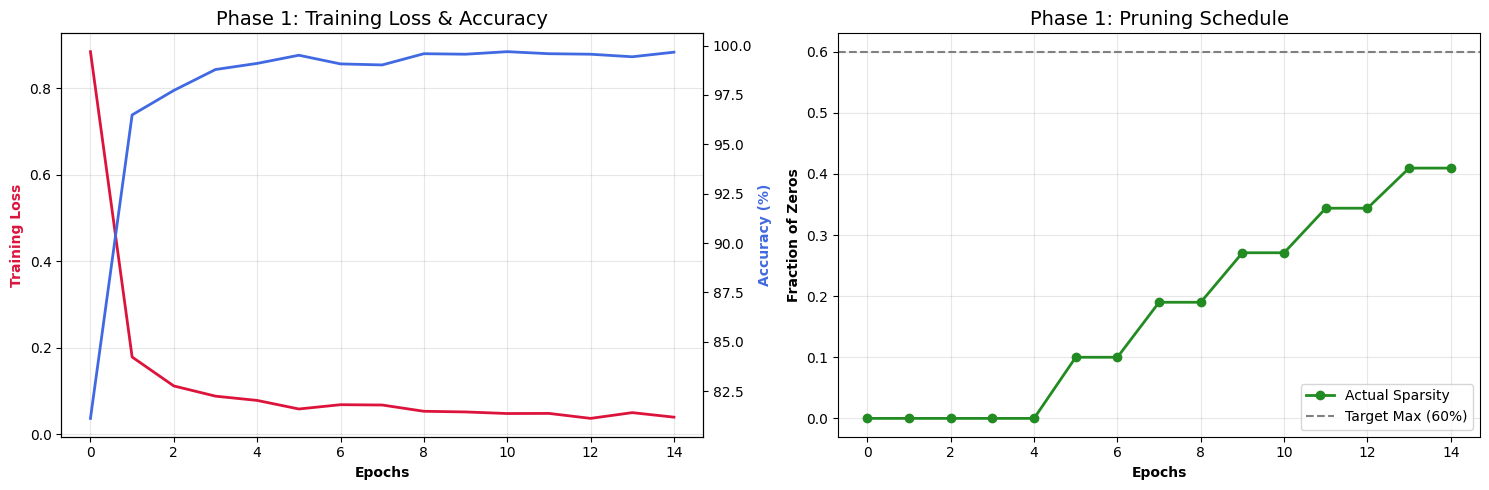

In [5]:
def get_sparsity(model):
    total_zeros, total_elements = 0, 0
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)) and hasattr(module, 'weight') and module.weight is not None:
            total_zeros += float(torch.sum(module.weight == 0))
            total_elements += float(module.weight.nelement())
    return total_zeros / total_elements if total_elements > 0 else 0.0

def apply_global_pruning(model, amount):
    parameters_to_prune = [(m, 'weight') for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear))]
    prune.global_unstructured(parameters_to_prune, pruning_method=prune.L1Unstructured, amount=amount)

print("Starting Training")
model = get_base_model()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

best_loss = float('inf')
epochs_without_improvement = 0
current_sparsity = 0.0
history = {'epoch': [], 'loss': [], 'acc': [], 'sparsity': []}

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    actual_sparsity = get_sparsity(model)
    
    history['epoch'].append(epoch)
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)
    history['sparsity'].append(actual_sparsity)

    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | Sparsity: {actual_sparsity:.4f}")

    if epoch >= 4 and epoch % 2 == 0 and current_sparsity < 0.6:
        current_sparsity += 0.1
        print(f" -> Pruning to Target Sparsity: {current_sparsity:.2f}")
        apply_global_pruning(model, 0.1)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

for module in model.modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        try: prune.remove(module, 'weight')
        except: pass
torch.save(model.state_dict(), "resnet18_pruned.pth")

plot_training_progress(history)

### Phase 2: K-Means 4-Bit Quantization


=== PHASE 2: 4-BIT QUANTIZATION ===


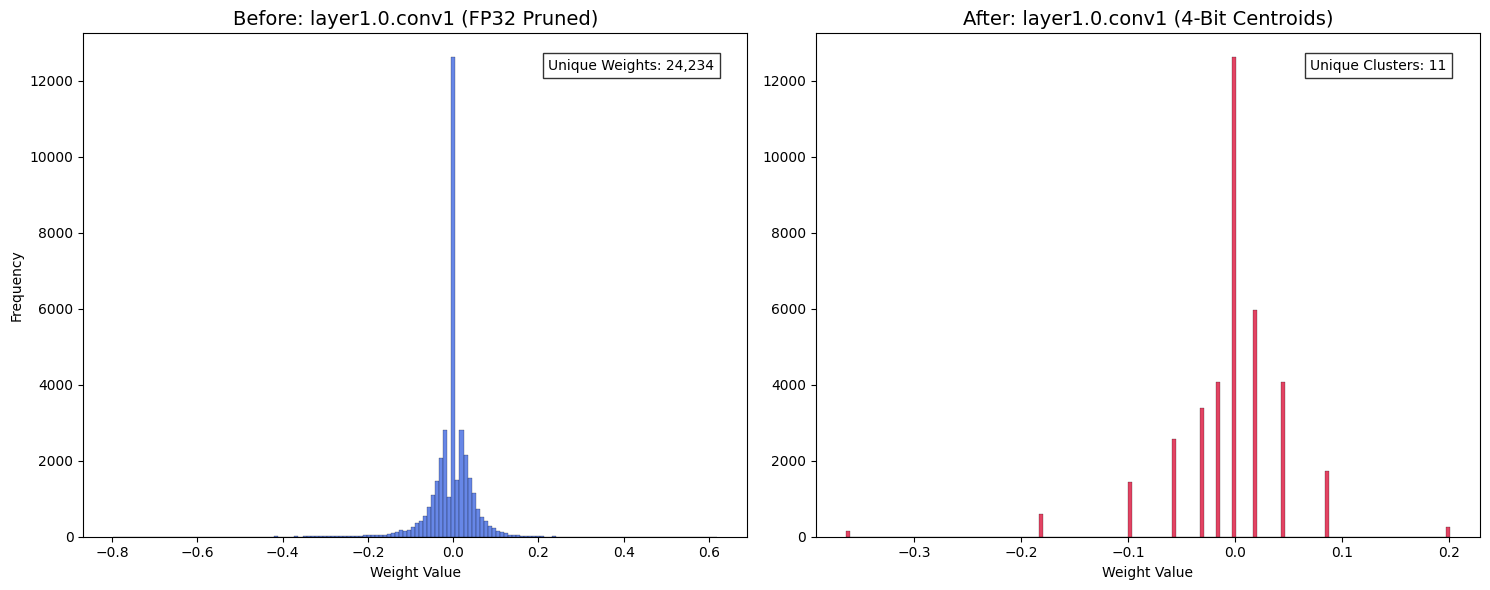

In [6]:
print("\nStart Qunatization")
def apply_model_quantization(model, bitwidth=4):
    codebooks = {}
    with torch.no_grad():
        for name, module in model.named_modules():
            if name in ['conv1', 'fc']: continue
            if isinstance(module, (nn.Conv2d, nn.Linear)) and hasattr(module, 'weight'):
                zero_mask = (module.weight.data == 0)
                kmeans = KMeans(n_clusters=(2**bitwidth)-1, mode='euclidean', verbose=0)
                labels = kmeans.fit_predict(module.weight.data.reshape(-1, 1)).to(torch.long)
                centroids = kmeans.centroids.to(torch.float).view(-1)
                
                module.weight.data.copy_(centroids[labels].view_as(module.weight.data))
                module.weight.data[zero_mask] = 0.0
                codebooks[name] = Codebook(centroids, labels)
    return codebooks

model.load_state_dict(torch.load("resnet18_pruned.pth", weights_only=True))
codebooks = apply_model_quantization(model, bitwidth=4)

compressed_dict = {}
for name, codebook in codebooks.items():
    module = dict(model.named_modules())[name]
    zero_idx = torch.abs(codebook.centroids).argmin().item()
    labels = codebook.labels.cpu().long()
    labels[(module.weight.data.cpu() == 0).view(-1)] = zero_idx
    
    lbls_byte = labels.byte()
    if lbls_byte.numel() % 2 != 0: lbls_byte = torch.cat([lbls_byte, torch.zeros(1, dtype=torch.byte)])
    packed = (lbls_byte.view(-1, 2)[:, 0] << 4) | lbls_byte.view(-1, 2)[:, 1]
    compressed_dict[name] = {'centroids': codebook.centroids.cpu(), 'packed_indices': packed, 'shape': module.weight.shape, 'zero_idx': zero_idx}

compressed_dict['metadata'] = {k: v.cpu() for k, v in model.state_dict().items() if not (k.endswith('.weight') and k.replace('.weight', '') in codebooks)}
torch.save(compressed_dict, "resnet18_4bit_packed.pth")

plot_weight_distributions('layer1.0.conv1')

### Phase 3: Post-Quantization Fine Tuning

In [7]:
print("\nStart Post-Quant Training")
model, codebooks = unpack_4bit_model("resnet18_4bit_packed.pth")
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        with torch.no_grad():
            for name, module in model.named_modules():
                if name in codebooks and module.weight.grad is not None:
                    cb = codebooks[name]
                    flat_grad, flat_labels = module.weight.grad.view(-1), cb.labels.view(-1)
                    for i in range(16):
                        mask = (flat_labels == i)
                        if mask.any(): flat_grad[mask] = flat_grad[mask].mean()
                    flat_grad[flat_labels == cb.zero_idx] = 0.0
        
        optimizer.step()
        
        with torch.no_grad():
            for name, module in model.named_modules():
                if name in codebooks:
                    cb = codebooks[name]
                    module.weight.data.view(-1)[cb.labels.view(-1) == cb.zero_idx] = 0.0

        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    print(f"Epoch [{epoch+1}/3] | Loss: {running_loss/len(train_loader):.4f} | Acc: {100 * correct / total:.2f}%")

torch.save(model.state_dict(), "./produce_net.pth")


=== PHASE 3: FINE-TUNING ===


/home/arberube/ODDL/labEnv/lib/python3.13/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


FT Epoch [1/3] | Loss: 0.0814 | Acc: 98.55%


/home/arberube/ODDL/labEnv/lib/python3.13/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


FT Epoch [2/3] | Loss: 0.0698 | Acc: 99.35%


/home/arberube/ODDL/labEnv/lib/python3.13/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


FT Epoch [3/3] | Loss: 0.0608 | Acc: 99.41%


### Final Benchmarks


=== FINAL BENCHMARKS ===
Baseline Accuracy:   98.44% | Size: 42.77 MB
Fine-Tuned Accuracy: 98.65% | Size: 5.53 MB
Computational MACS:  1.82 B


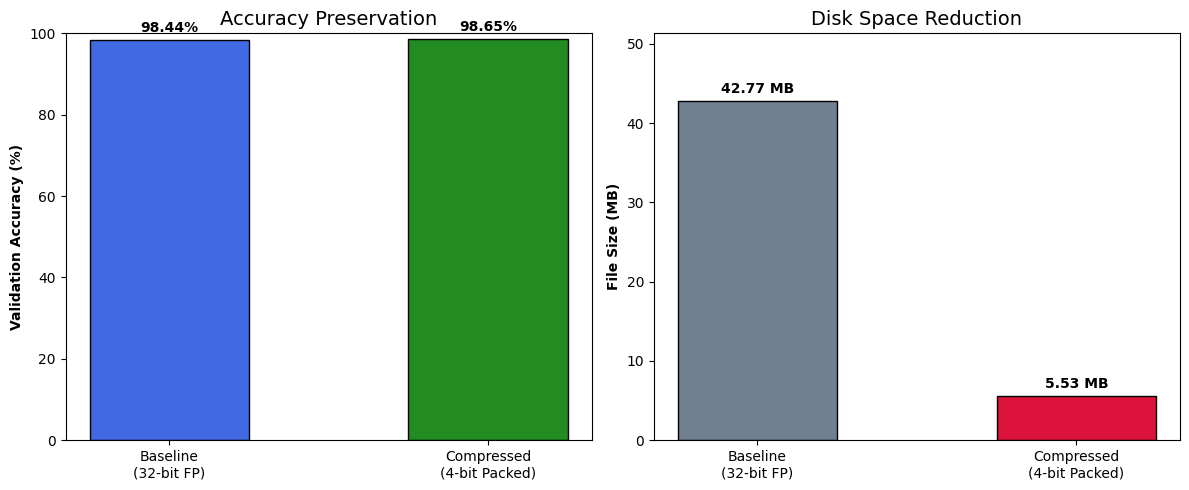

In [8]:
print("\nFINAL BENCHMARKS")

orig_model = get_base_model()
orig_model.load_state_dict(torch.load("resnet18_pruned.pth", weights_only=True))
acc_orig = evaluate_model(orig_model, val_loader)
acc_quant = evaluate_model(model, val_loader)

size_orig = os.path.getsize('resnet18_pruned.pth') / 1024**2
size_quant = os.path.getsize('resnet18_4bit_packed.pth') / 1024**2

print(f"Baseline Accuracy:   {acc_orig:.2f}% | Size: {size_orig:.2f} MB")
print(f"Fine-Tuned Accuracy: {acc_quant:.2f}% | Size: {size_quant:.2f} MB")

try:
    from thop import profile
    macs = profile(model, inputs=(torch.randn(1, 3, 224, 224).to(DEVICE), ), verbose=False)[0]
    print(f"Computational MACS:  {macs/1e9:.2f} B")
except:
    pass

plot_final_benchmarks(acc_orig, size_orig, acc_quant, size_quant)

**End of Project**